# Week 5 — calibrated discrete covariate HMMs on DTU CO2 data

**Scope.** One room, 30-minute aggregation, **discrete** models only: a Gaussian and an
autoregressive emission with a covariate-driven (`DynamicTransition`) transition, plus a
**second-order** covariate transition (`DynamicTransitionHigherOrder`) that asks whether the
chain's memory buys anything once the covariates are already in the transition.

**Data.** The cleaning, calibration, covariate construction and splitting all live in
`drivers/clean_dtu_data.py` — run `uv run python -m drivers.clean_dtu_data` once and this
notebook just *loads* `data/<room>/<tag>/{y,X}_{train,val,test}.csv`. That keeps the
preprocessing in one reviewable place and guarantees every notebook sees the same arrays.

**Calibration** (applied by the driver). The NDIR sensors drift, so the floor of a room's CO2
series sits wherever the sensor's zero happens to be rather than at the ~400 ppm outdoor
background. The driver shifts the whole series by one constant so its minimum is exactly
400 ppm. A pure shift leaves every difference, gap and dynamic untouched — it only makes the
level comparable across rooms and physically interpretable.

**Splits.** Chronological **train → validation → test**. Models are fitted on train only;
the validation block is where model choice is decided, and the test block is looked at last.
Covariates are z-scored with *training* statistics only, so nothing downstream leaks into the
scaling.

**Evaluation.** Rolling **6-hour-ahead** forecasts against a persistence baseline
(RMSE / MAPE / R2) on validation and test separately, residual diagnostics, and in-sample
LL / AIC / BIC.

## Imports and config

In [1]:
import jax
jax.config.update("jax_enable_x64", True)   # must come before anything touches JAX

from pathlib import Path

import pandas as pd
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from src.api.v4 import (
    HMM, GaussEmission, AutoregressiveGaussEmission,
    DynamicTransition, DynamicTransitionHigherOrder, ForwardAlgorithm, AIC, BIC,
)
from src.base.utils import transition_matrix_to_logits
from drivers.utils import (
    plot_hmm_diagnostics, load_base_data_path,
    load_train_data, load_val_data, load_test_data,
)

In [ ]:
# --- Which prepared dataset to read ------------------------------------
# Produced by: uv run python -m drivers.clean_dtu_data
# (room, bin, harmonics, weather columns and split fractions are all set there)
ROOM_SLUG = "room_009"
TAG       = "30min"

# --- Model / evaluation config -----------------------------------------
STATES        = 4
AR_LAGS       = 6
ORDER         = 2          # Markov order of the higher-order transition
HORIZON_HOURS = 6

## Load the prepared splits

Everything below comes from `drivers/clean_dtu_data.py`: the longest gap-free 30-min segment of
the room's series, baseline-calibrated, with its covariate matrix z-scored on training rows and
cut chronologically into train / validation / test.

`metadata.csv` carries the window, the split boundaries, the covariate names and the training
mean/std of every covariate — enough to rebuild the timestamps (the segment is gap-free on a
regular grid) and to un-standardise the covariates for plotting.

In [3]:
data_dir = Path(load_base_data_path()) / ROOM_SLUG / TAG
meta     = pd.read_csv(data_dir / "metadata.csv").iloc[0]

room_name      = meta["room_name"]
BIN            = meta["bin"]
BIN_SECONDS    = int(pd.Timedelta(BIN).total_seconds())
BASELINE_PPM   = float(meta["baseline_ppm"])
covariate_cols = meta["covariate_cols"].split("|")

ys_train, X_train_std = load_train_data(ROOM_SLUG, TAG)
ys_val,   X_val_std   = load_val_data(ROOM_SLUG, TAG)
ys_test,  X_test_std  = load_test_data(ROOM_SLUG, TAG)

# One contiguous series again, plus the two split boundaries as indices into it.
ys_agg    = jnp.concatenate([ys_train, ys_val, ys_test])
X_std     = jnp.concatenate([X_train_std, X_val_std, X_test_std])
TRAIN_IDX = len(ys_train)
VAL_IDX   = TRAIN_IDX + len(ys_val)
dates_agg = pd.date_range(meta["start"], periods=int(meta["n_bins"]), freq=BIN)

# Un-standardised covariates (X_std * std + mean) — only for the exploration plots below;
# every model is fitted on the standardised matrix.
x_mean = jnp.asarray([float(meta[f"mean_{c}"]) for c in covariate_cols])
x_std  = jnp.asarray([float(meta[f"std_{c}"])  for c in covariate_cols])
X_raw  = X_std * x_std + x_mean

num_covariates = X_std.shape[1]
# A DynamicTransition has no time-invariant matrix, so the stationary distribution is
# undefined — pass an explicit (uniform) initial distribution instead.
init_dist = jnp.full(STATES, 1.0 / STATES)

print(f"{room_name} ({ROOM_SLUG}/{TAG}) — {BIN} bins")
print(f"  window        : {dates_agg[0]} -> {dates_agg[-1]}  ({len(ys_agg)} bins)")
print(f"  baseline shift: {-float(meta['baseline_offset']):+.2f} ppm (min = {BASELINE_PPM:.0f} ppm)")
print(f"  train/val/test: {len(ys_train)}/{len(ys_val)}/{len(ys_test)} bins")
print(f"  boundaries    : {dates_agg[TRAIN_IDX]} | {dates_agg[VAL_IDX]}")
print(f"  covariates    : {num_covariates} ({', '.join(covariate_cols)})")

Room 009 (room_009/30min) — 30min bins
  window        : 2023-11-13 03:30:00 -> 2024-02-09 13:00:00  (4244 bins)
  baseline shift: +33.33 ppm (min = 400 ppm)
  train/val/test: 2758/637/849 bins
  boundaries    : 2024-01-09 14:30:00 | 2024-01-22 21:00:00
  covariates    : 15 (off_day, sin_week_1, cos_week_1, sin_tod_1, cos_tod_1, sin_tod_2, cos_tod_2, sin_tod_3, cos_tod_3, mean_temp, mean_relative_hum, mean_wind_speed, mean_pressure, mean_cloud_cover, mean_radiation)


## Data exploration

Four views before any model is fitted: where the splits fall, what the daily cycle looks like on
work days versus off days, how the covariates move against each other, and what the raw covariate
traces actually look like over a representative fortnight.

### The calibrated series and the split boundaries

A sanity check on the split: each block should cover enough days to contain several full daily
cycles, and the validation and test blocks should not look structurally different from training
(a holiday-dominated test block, say, would make every comparison below a comparison of periods
rather than of models).

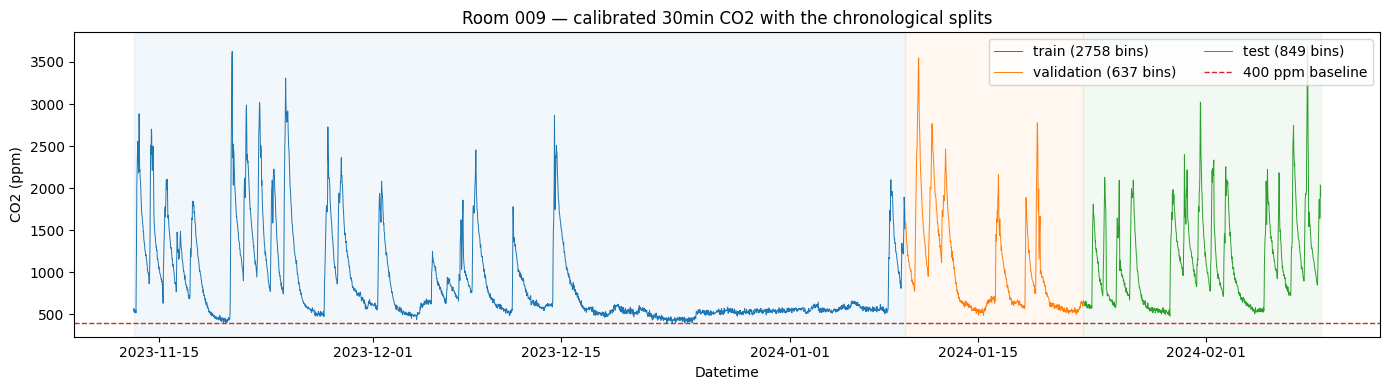

               bins    days      min     mean      max      std
train          2758    57.5    400.0    857.9   3624.3    512.8
validation      637    13.3    490.3   1018.0   3548.0    576.4
test            849    17.7    481.0   1110.4   3687.3    523.8


In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
blocks = [("train", 0, TRAIN_IDX, "tab:blue"),
          ("validation", TRAIN_IDX, VAL_IDX, "tab:orange"),
          ("test", VAL_IDX, len(ys_agg), "tab:green")]

for label, lo, hi, colour in blocks:
    ax.plot(dates_agg[lo:hi], np.asarray(ys_agg[lo:hi]), lw=0.7, color=colour,
            label=f"{label} ({hi - lo} bins)")
    ax.axvspan(dates_agg[lo], dates_agg[hi - 1], color=colour, alpha=0.06)

ax.axhline(BASELINE_PPM, color="tab:red", ls="--", lw=1.0, label=f"{BASELINE_PPM:.0f} ppm baseline")
ax.set_title(f"{room_name} — calibrated {BIN} CO2 with the chronological splits")
ax.set_ylabel("CO2 (ppm)")
ax.set_xlabel("Datetime")
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

print(f"{'':<12}{'bins':>7}{'days':>8}{'min':>9}{'mean':>9}{'max':>9}{'std':>9}")
for label, lo, hi, _ in blocks:
    blk = np.asarray(ys_agg[lo:hi])
    days = (hi - lo) * BIN_SECONDS / 86400
    print(f"{label:<12}{hi - lo:>7}{days:>8.1f}{blk.min():>9.1f}{blk.mean():>9.1f}"
          f"{blk.max():>9.1f}{blk.std():>9.1f}")

### Daily profile, work days versus off days

The `off_day` covariate (weekend or Danish public holiday) is the one flag the transition gets,
so it is worth checking it separates anything. The band is the interquartile range across days,
which is where the *state* structure lives: a wide band in working hours means the room is
sometimes occupied and sometimes not at the same clock time — exactly what a hidden state is
supposed to absorb, and what a purely deterministic time-of-day regression could not.

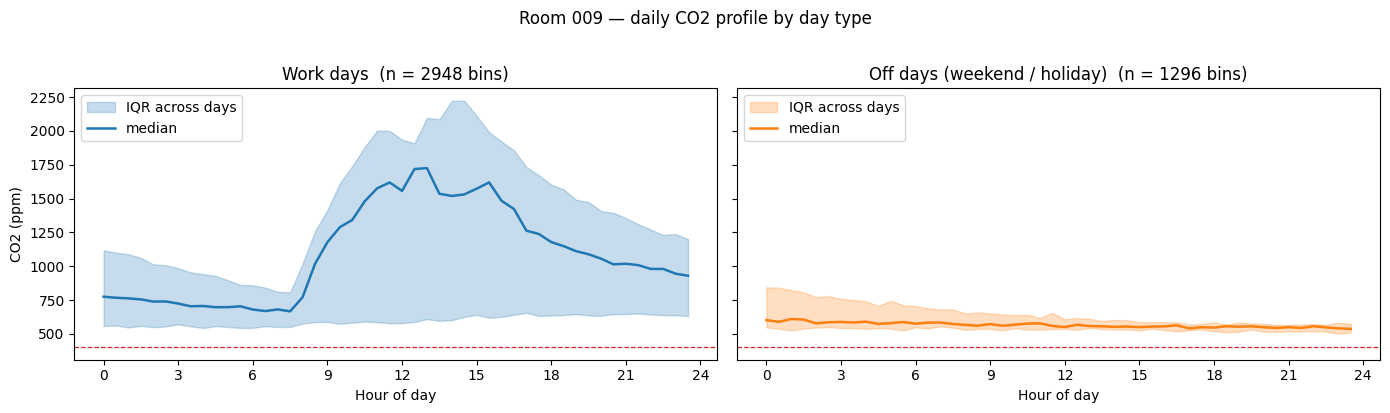

In [5]:
off_day_raw = np.asarray(X_raw[:, covariate_cols.index("off_day")]) > 0.5
hour_of_day = dates_agg.hour + dates_agg.minute / 60.0

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (label, mask, colour) in zip(axes, [("Work days", ~off_day_raw, "tab:blue"),
                                            ("Off days (weekend / holiday)", off_day_raw, "tab:orange")]):
    prof = pd.DataFrame({"hour": hour_of_day[mask], "co2": np.asarray(ys_agg)[mask]})
    q = prof.groupby("hour")["co2"].quantile([0.25, 0.5, 0.75]).unstack()
    ax.fill_between(q.index, q[0.25], q[0.75], color=colour, alpha=0.25, label="IQR across days")
    ax.plot(q.index, q[0.5], color=colour, lw=1.8, label="median")
    ax.axhline(BASELINE_PPM, color="tab:red", ls="--", lw=0.9)
    ax.set_title(f"{label}  (n = {mask.sum()} bins)")
    ax.set_xlabel("Hour of day")
    ax.set_xticks(range(0, 25, 3))
    ax.legend(loc="upper left")
axes[0].set_ylabel("CO2 (ppm)")
fig.suptitle(f"{room_name} — daily CO2 profile by day type", y=1.02)
plt.tight_layout()
plt.show()

### How the covariates relate to CO2 and to each other

Pearson correlations on the **training block only**. Two things to read off it: which covariates
carry any marginal signal about the level of CO2 at all, and which pairs are near-collinear.
Collinearity matters here because the transition spends `D * STATES * (STATES - 1)` parameters on
`beta` — two covariates saying the same thing cost the full budget and buy one covariate's worth
of information.

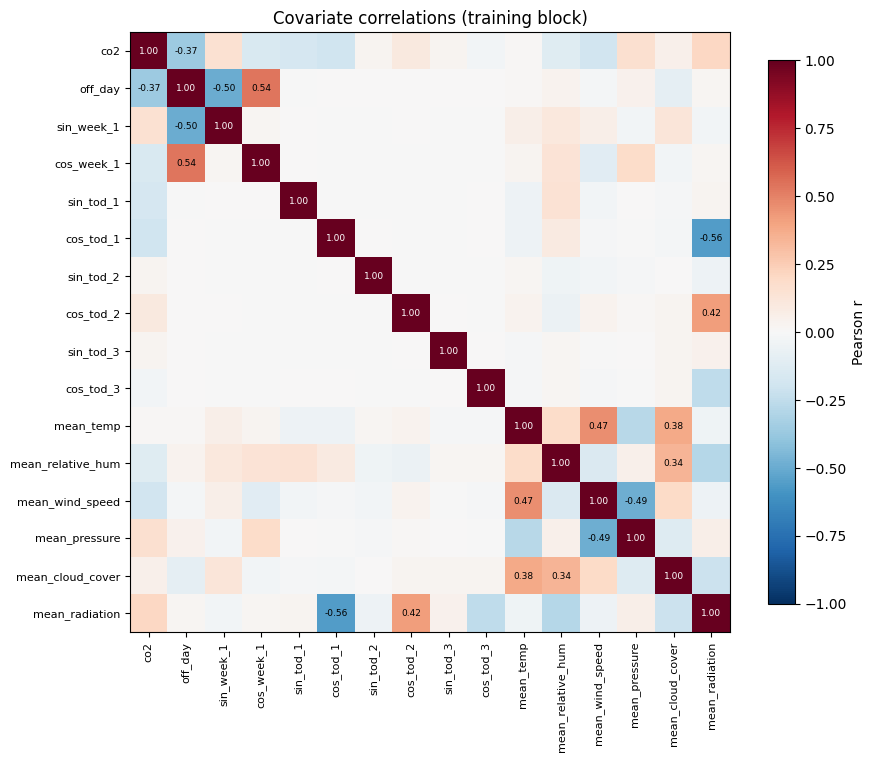

Marginal correlation with CO2 (training block), strongest first:
off_day             -0.367
mean_radiation       0.204
cos_tod_1           -0.198
mean_wind_speed     -0.188
sin_tod_1           -0.165
mean_pressure        0.163
cos_week_1          -0.155
sin_week_1           0.150
mean_relative_hum   -0.122
cos_tod_2            0.100
mean_cloud_cover     0.050
sin_tod_2            0.029
cos_tod_3           -0.026
sin_tod_3            0.024
mean_temp            0.011
Name: co2, dtype: float64


In [6]:
expl = pd.DataFrame(np.asarray(X_raw[:TRAIN_IDX]), columns=covariate_cols)
expl.insert(0, "co2", np.asarray(ys_train))
corr = expl.corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        if abs(v) >= 0.3:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Covariate correlations (training block)")
plt.tight_layout()
plt.show()

print("Marginal correlation with CO2 (training block), strongest first:")
print(corr["co2"].drop("co2").reindex(corr["co2"].drop("co2").abs().sort_values(ascending=False).index).round(3))

### Covariate traces over a representative fortnight

The standardised matrix as the transition actually sees it. The deterministic calendar terms
(off-day flag, weekly and daily harmonics) are exactly periodic by construction; the weather
terms are the only ones carrying genuinely new information per day, and they move on a much
slower scale than the CO2 series does.

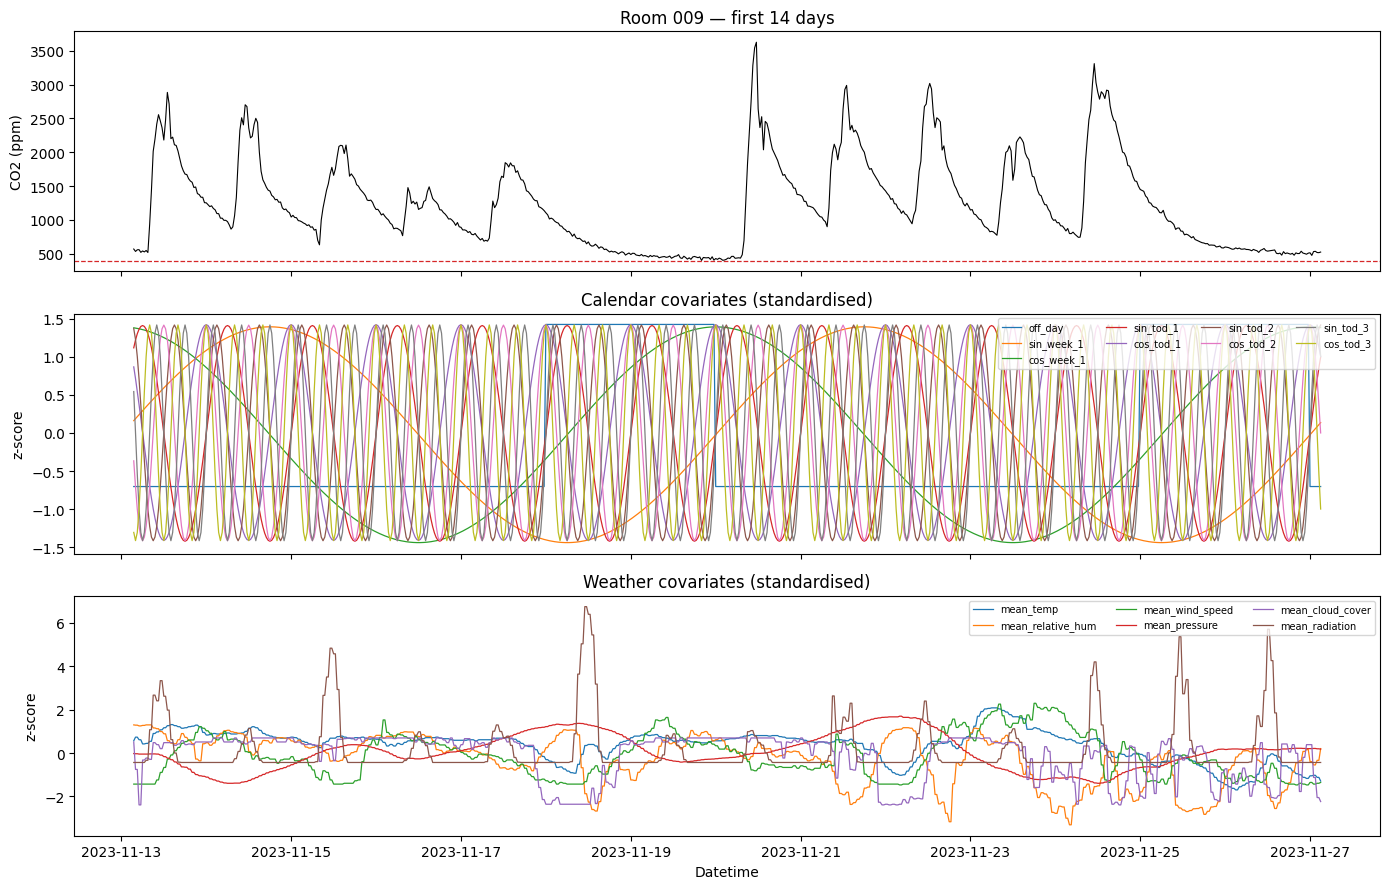

In [7]:
WINDOW_DAYS = 14
w = slice(0, int(WINDOW_DAYS * 86400 / BIN_SECONDS))

calendar_cols = [c for c in covariate_cols if c.startswith(("off_day", "sin_", "cos_"))]
weather_plot  = [c for c in covariate_cols if c not in calendar_cols]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(dates_agg[w], np.asarray(ys_agg[w]), lw=0.8, color="black")
axes[0].axhline(BASELINE_PPM, color="tab:red", ls="--", lw=0.9)
axes[0].set_ylabel("CO2 (ppm)")
axes[0].set_title(f"{room_name} — first {WINDOW_DAYS} days")

for c in calendar_cols:
    axes[1].plot(dates_agg[w], np.asarray(X_std[w, covariate_cols.index(c)]), lw=0.9, label=c)
axes[1].set_ylabel("z-score")
axes[1].set_title("Calendar covariates (standardised)")
axes[1].legend(loc="upper right", ncol=4, fontsize=7)

for c in weather_plot:
    axes[2].plot(dates_agg[w], np.asarray(X_std[w, covariate_cols.index(c)]), lw=0.9, label=c)
axes[2].set_ylabel("z-score")
axes[2].set_xlabel("Datetime")
axes[2].set_title("Weather covariates (standardised)")
axes[2].legend(loc="upper right", ncol=3, fontsize=7)

plt.tight_layout()
plt.show()

## Fit the two discrete covariate HMMs

Both use `DynamicTransition` (covariate-driven) with `ts=None`, i.e. unit 30-min steps. Seeds come
from the calibrated training series, so the monotone mean construction
`mu0 + cumsum(exp(log_mu_diff))` starts in the right range. The autoregressive model is
warm-started from the fitted Gaussian model (emission means/sigmas and transition), with the AR
coefficients at zero — at `phi = 0` it *is* the Gaussian model, so the fit can only improve on it.

In [8]:
def state_means(emission, ys):
    """Per-state base means, whichever emission is asked.

    `GaussEmission` exposes them directly as `mu`; the autoregressive emission splits
    them into `mu_vals` (state base) and `mu` (base + AR term on the previous value).
    """
    return getattr(emission, "mu_vals", emission.mu)(0, ys)


mu_seed    = jnp.quantile(ys_train, jnp.linspace(0.05, 0.95, STATES)) 
mu_seed = mu_seed.at[0].set(450)  # avoid degenerate state

sigma_seed = jnp.std(ys_train) * jnp.ones(STATES)
tm_seed    = jnp.full((STATES, STATES), 0.1).at[jnp.diag_indices(STATES)].set(0.7)
beta_init  = jnp.zeros((num_covariates, STATES, STATES - 1))

print("=== Gaussian HMM + covariates (30-min, calibrated) ===")
gauss_cov = HMM(
    emission=GaussEmission.from_params(mu_seed, sigma_seed),
    transition=DynamicTransition(transition_matrix_to_logits(tm_seed), beta_init),
    inital_distribution=init_dist,
)
gauss_cov.fit(ys=ys_train, ts=None, xs=X_train_std, tol=1e-2, frozen={"mu0": False})  # freeze the lowest state mean to avoid degenerate state
print("  log-likelihood:", gauss_cov.log_likelihood())
print("  converged:", gauss_cov.hmm_results.convergence)
print(f"Mu (per state): {np.asarray(gauss_cov.emission.mu(t= 0, ys=0))}")

=== Gaussian HMM + covariates (30-min, calibrated) ===
  log-likelihood: -17040.792076865207
  converged: True
Mu (per state): [ 450.          559.15819516 1302.61916284]


In [9]:
print("=== Autoregressive HMM + covariates (30-min, calibrated) ===")
mu_warm    = state_means(gauss_cov.emission, ys_train)          # fitted state means
sigma_warm = jnp.exp(gauss_cov.emission.log_sigma)

ar_cov = HMM(
    emission=AutoregressiveGaussEmission.from_params(
        mu_warm, sigma_warm, jnp.zeros((AR_LAGS, STATES))
    ),
    transition=DynamicTransition(
        gauss_cov.transition.transition_logits, gauss_cov.transition.beta
    ),
    inital_distribution=init_dist,
)
ar_cov.fit(ys=ys_train, ts=None, xs=X_train_std, tol=1e-2, frozen={"mu0": False})  # freeze the lowest state mean to avoid degenerate state
print("  log-likelihood:", ar_cov.log_likelihood())
print("  converged:", ar_cov.hmm_results.convergence)
print("  phi (per state):", np.asarray(ar_cov.emission.phi()))
print("  AR coefficients (per state):", np.asarray(ar_cov.emission.mu_vals(t=0, ts = 0, ys= 0)))

=== Autoregressive HMM + covariates (30-min, calibrated) ===
  log-likelihood: -13448.357608279359
  converged: True
  phi (per state): [[0.3856582  0.95159462 0.86833101]]
  AR coefficients (per state): [ 450.          562.26277969 2283.00480756]


## Fit a second-order covariate HMM

The chain now runs on **augmented states** `(s_{t-1}, s_t)` — `STATES**ORDER = 16` of them — with
`DynamicTransitionHigherOrder`: covariate-driven like `DynamicTransition`, order-`ORDER` like
`StaticTransitionHigherOrder`. Structurally impossible moves (those whose history does not line up)
are pinned to zero probability, so each augmented state still has only `STATES` real successors.

Two things keep the comparison honest:

- **Tied covariate effects.** `beta` stays `(D, STATES, STATES-1)`, broadcast to every augmented row
  sharing the same current base state. The covariate budget is identical to the first-order model, so
  the only thing added is memory.
- **An exact warm start.** `DynamicTransitionHigherOrder.from_first_order(ar_cov.transition)` lifts
  the fitted first-order transition onto the augmented space, re-referencing the logits so the
  lifted chain reproduces the first-order one at *every* covariate value. The fit therefore starts
  at the first-order optimum.

The emission is autoregressive again, with the `STATES` base means tiled up to the 16 augmented
states (`mu_vals` already does that), so the mean depends only on the current base state.


In [10]:
print("=== Second-order HMM + covariates (30-min, calibrated) ===")
AUG_STATES = STATES ** ORDER

# Augmented state i encodes (s_{t-1}, s_t) as i = s_{t-1} * STATES + s_t, so the current
# base state is i % STATES. `mu_vals` tiles the STATES base means up to len(log_sigma),
# so sigma and phi must be *tiled* (not repeated) to stay aligned with that convention.
mu_so    = state_means(ar_cov.emission, ys_train)[:STATES]         # base means, (STATES,)
sigma_so = jnp.tile(jnp.exp(ar_cov.emission.log_sigma), STATES)    # (AUG_STATES,)
phi_so   = jnp.tile(ar_cov.emission.phi(), (1, STATES))            # (AR_LAGS, AUG_STATES)

so_cov = HMM(
    emission=AutoregressiveGaussEmission.from_params(mu_so, sigma_so, phi_so),
    transition=DynamicTransitionHigherOrder.from_first_order(ar_cov.transition, order=ORDER),
    # No stationary distribution for a covariate-driven chain — uniform over the 16
    # augmented states, whose base-state marginal is the uniform used by the other models.
    inital_distribution=jnp.full(AUG_STATES, 1.0 / AUG_STATES),
)

# Check the lift before spending a fit on it: at the seed this model *is* the fitted
# AR + covariate model, so the two log-likelihoods must agree.
ll_seed = so_cov.log_likelihood(ys=ys_train, xs=X_train_std)
ll_ar   = ar_cov.log_likelihood(ys=ys_train, xs=X_train_std)
print(f"  seed LL {ll_seed:.4f} vs AR+cov LL {ll_ar:.4f}  (difference {ll_seed - ll_ar:.2e})")

so_cov.fit(ys=ys_train, ts=None, xs=X_train_std, tol=1e-2)
print("  log-likelihood:", so_cov.log_likelihood())
print("  converged:", so_cov.hmm_results.convergence)
print("  transition params:", so_cov.transition.transition_logits.size,
      "baseline logits +", so_cov.transition.beta.size, "beta")

# Only the means stay tied to the STATES base states — the fit gets one sigma per
# augmented state, and an almost-never-visited state lets its sigma run toward 0
# (the usual unbounded-likelihood spike). Show occupancy and sigma side by side so
# that is visible rather than buried in the log-likelihood.
utt_so = np.asarray(so_cov.state_results.utt).reshape(len(ys_train), -1)
print("\n  mean filtered occupancy (rows = s_{t-1}, cols = s_t):")
print(np.round(utt_so.mean(axis=0).reshape(-1, STATES), 4))
print("  fitted sigmas (same layout):")
print(np.round(np.asarray(jnp.exp(so_cov.emission.log_sigma)).reshape(-1, STATES), 3))


=== Second-order HMM + covariates (30-min, calibrated) ===
  seed LL -13448.3576 vs AR+cov LL -13448.3576  (difference 0.00e+00)
  log-likelihood: -13409.557860935987
  converged: True
  transition params: 18 baseline logits + 90 beta

  mean filtered occupancy (rows = s_{t-1}, cols = s_t):
[[7.080e-02 8.000e-04 0.000e+00]
 [7.000e-04 8.109e-01 8.800e-03]
 [0.000e+00 9.100e-03 9.900e-02]]
  fitted sigmas (same layout):
[[1.81790e+01 1.00000e-03 1.75025e+02]
 [1.14610e+01 2.47720e+01 1.27479e+02]
 [1.80800e+01 8.90480e+01 2.13444e+02]]


In [11]:
models = {"Gaussian + cov": gauss_cov,
          "Autoregressive + cov": ar_cov,
          "Second-order + cov": so_cov}

for name, m in models.items():
    # Means stay tied to the STATES base states (`mu_vals` tiles them), so one period
    # of them is the whole story. Sigmas are not tied: the second-order model fits one
    # per augmented state, so print the full grid for it.
    mu = np.asarray(state_means(m.emission, ys_train))
    sd = np.asarray(jnp.exp(m.emission.log_sigma))
    print(f"{name}")
    print(f"  state means : {np.round(mu[:STATES], 1)}")
    if sd.size == STATES:
        print(f"  state sigmas: {np.round(sd, 1)}")
    else:
        print(f"  state sigmas (rows = s_t-1, cols = s_t):")
        print(np.round(sd.reshape(-1, STATES), 2))


Gaussian + cov
  state means : [ 450.   559.2 1302.6]
  state sigmas: [ 24.1  41.8 540.2]
Autoregressive + cov
  state means : [ 450.   562.3 2283. ]
  state sigmas: [ 18.1  24.9 206.2]
Second-order + cov
  state means : [ 443.2  543.8 2298.2]
  state sigmas (rows = s_t-1, cols = s_t):
[[ 18.18   0.   175.03]
 [ 11.46  24.77 127.48]
 [ 18.08  89.05 213.44]]


## In-sample fit criteria

In [12]:
rows = []
for name, m in models.items():
    res = m.hmm_results
    rows.append({
        "Model": name,
        "LL": res.log_likelihood,
        "#Params": res.num_params,
        "AIC": AIC(res),
        "BIC": BIC(res, len(ys_train)),
        "Converged": res.convergence,
    })

fit_table = pd.DataFrame(rows)
fit_table["dAIC"] = fit_table["AIC"] - fit_table["AIC"].min()
fit_table["dBIC"] = fit_table["BIC"] - fit_table["BIC"].min()
fit_table = fit_table[["Model", "LL", "#Params", "AIC", "dAIC", "BIC", "dBIC", "Converged"]]
fit_table.round(2)

,Model,LL,#Params,AIC,dAIC,BIC,dBIC,Converged
0,Gaussian + cov,-17040.79,102,34285.58,7208.47,34889.65,7161.10,True
1,Autoregressive + cov,-13448.36,105,27106.72,29.60,27728.55,0.00,True
2,Second-order + cov,-13409.56,129,27077.12,0.00,27841.09,112.53,True


## Residual diagnostics

`plot_hmm_diagnostics` (from `drivers/utils.py`) shows the log-likelihood per solver iteration,
a normal Q-Q plot of the forecast pseudo-residuals, and their ACF. Under a well-specified model
the pseudo-residuals are i.i.d. standard normal, so the Q-Q line should be straight and the ACF
flat.

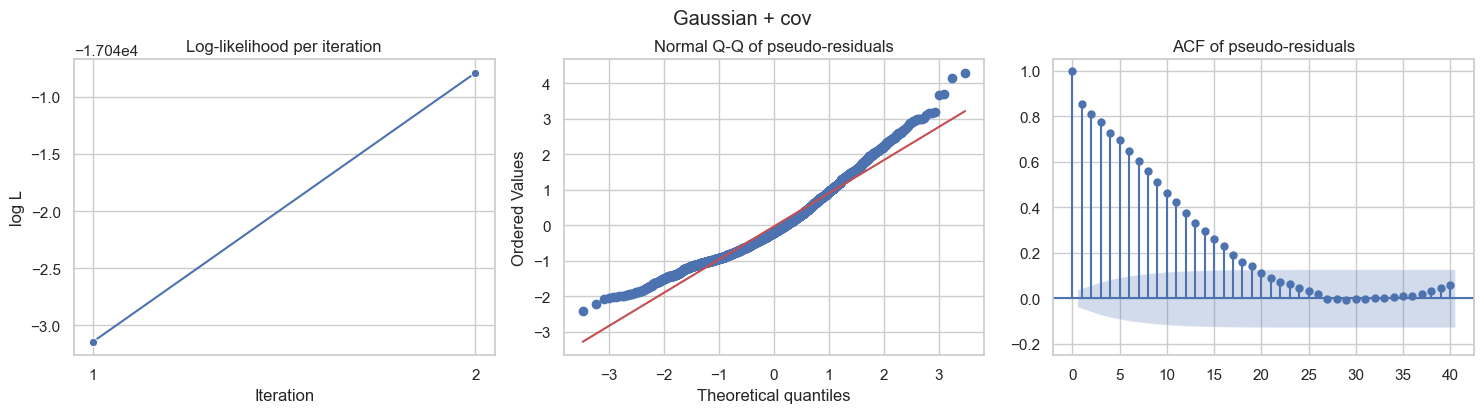

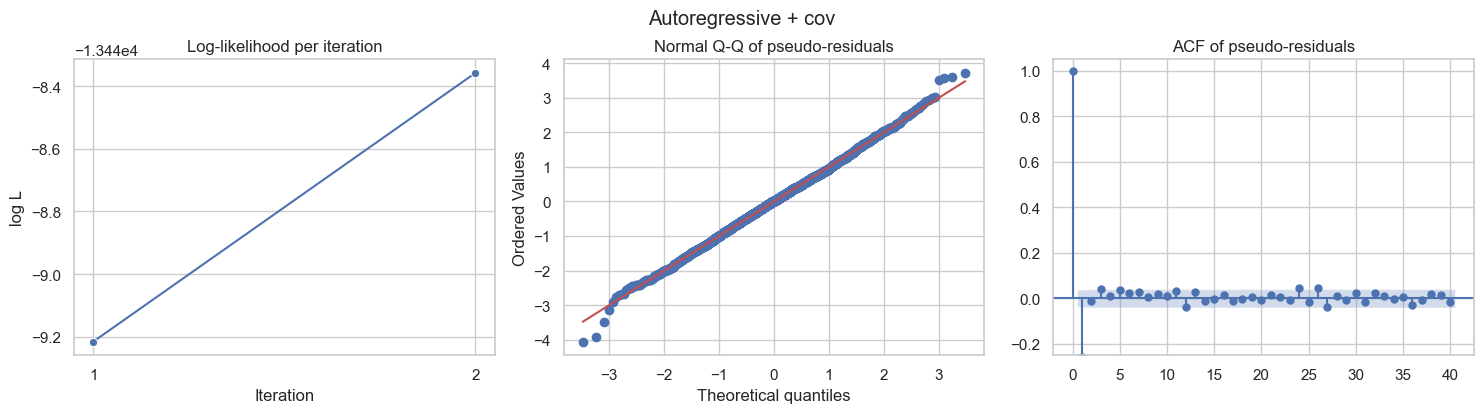

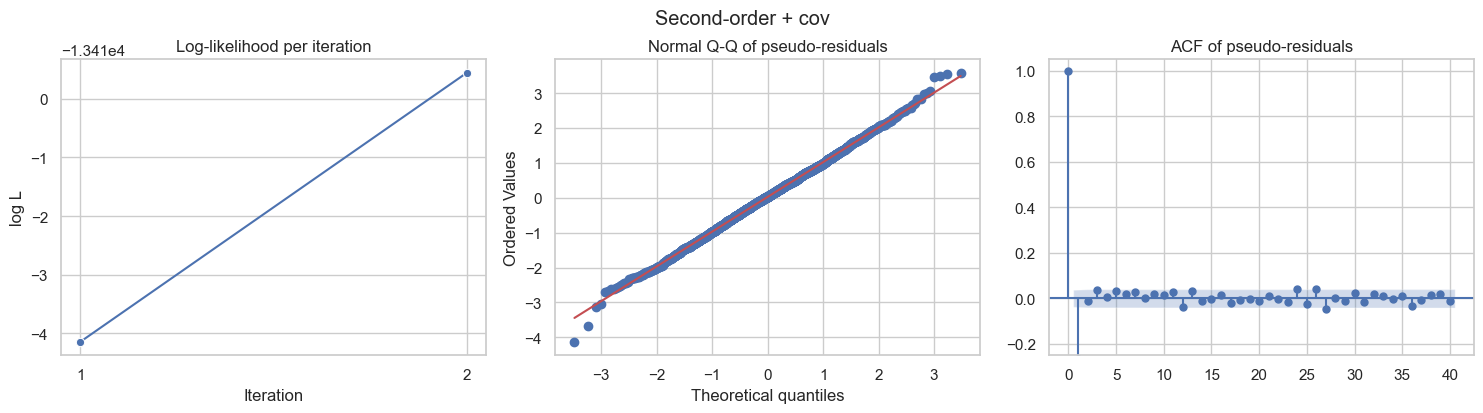

In [13]:
for name, m in models.items():
    fig = plot_hmm_diagnostics(m)
    fig.suptitle(name, y=1.03)
    plt.show()

### Decoded states over the training window

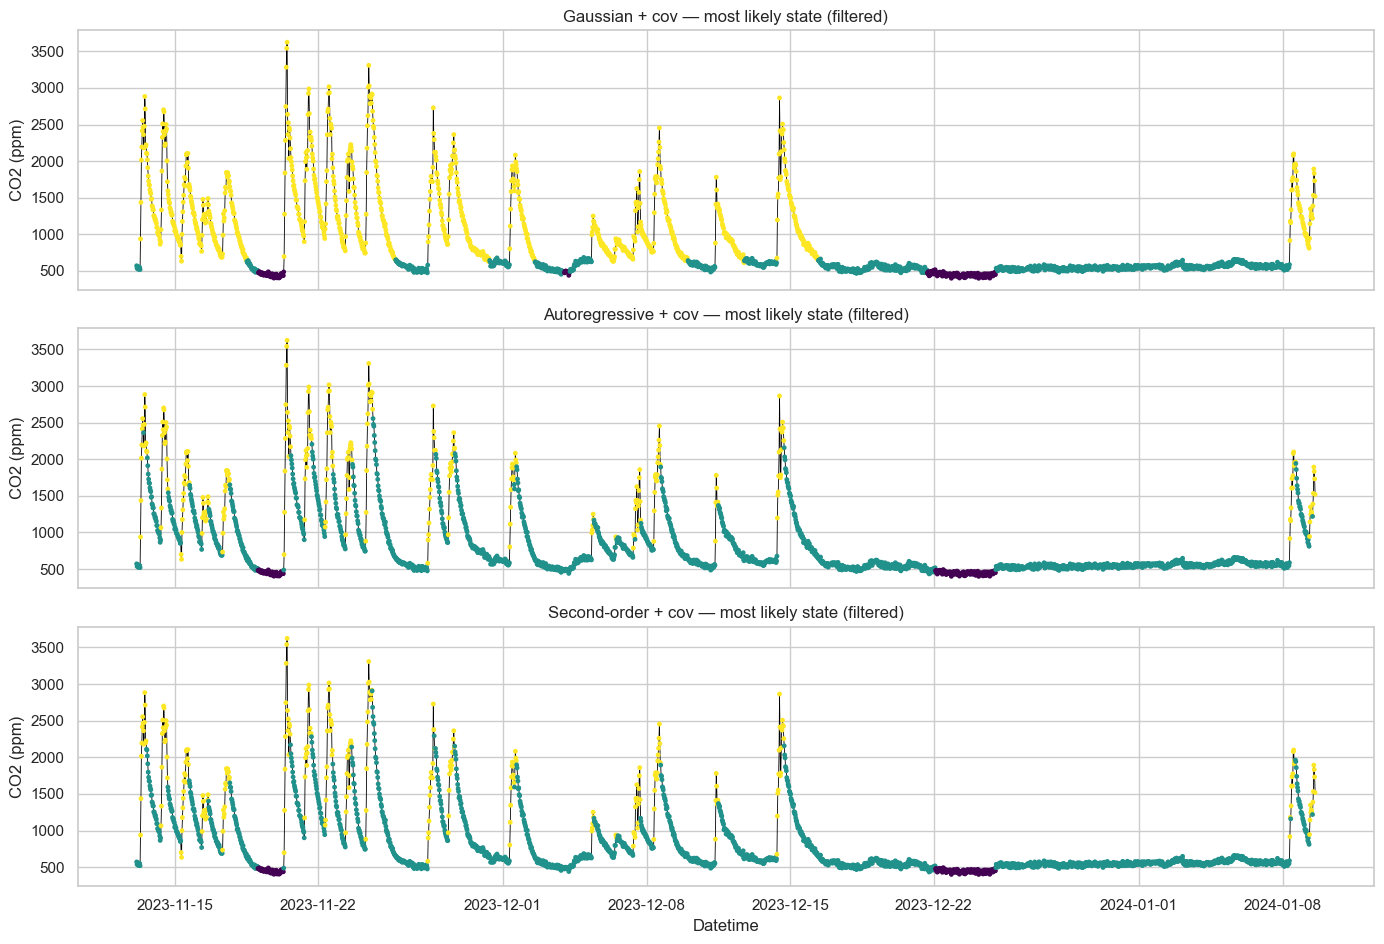

In [14]:
fig, axes = plt.subplots(len(models), 1, figsize=(14, 3.2 * len(models)), sharex=True)
for ax, (name, m) in zip(np.atleast_1d(axes), models.items()):
    utt = np.asarray(m.state_results.utt).reshape(len(ys_train), -1)
    # Augmented index i has current base state i % STATES, so the second-order
    # model shares one colour scale with the first-order ones.
    decoded = utt.argmax(axis=1) % STATES
    ax.plot(dates_agg[:TRAIN_IDX], np.asarray(ys_train), color="black", lw=0.6, zorder=1)
    ax.scatter(dates_agg[:TRAIN_IDX], np.asarray(ys_train), c=decoded, cmap="viridis",
               s=6, zorder=2)
    ax.set_title(f"{name} — most likely state (filtered)")
    ax.set_ylabel("CO2 (ppm)")
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
plt.tight_layout()
plt.show()

## Predictive metrics

In [15]:
def rmse(y_true, y_pred):
    return float(jnp.sqrt(jnp.mean((y_true - y_pred) ** 2)))

def r2_score(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred) ** 2)
    ss_tot = jnp.sum((y_true - jnp.mean(y_true)) ** 2)
    return float(1 - ss_res / ss_tot)

def mape(y_true, y_pred):
    return float(jnp.mean(jnp.abs((y_true - y_pred) / y_true)) * 100)

## Rolling 6-hour-ahead forecast

At **every** anchor in an evaluation block we take the causal filtered state and propagate it `K`
steps forward through the model's own transition matrices, then compare the emission mean to the
CO2 actually realised that far ahead. Filtering is causal, so one forward pass over the whole
series leaks nothing — the covariates at future steps are exogenous time/weather features, not
the target.

- `K = 6 h / 30 min = 12` steps.
- **Autoregressive:** the emission mean depends on the previous observation, unknown in the
  future, so the model's own running prediction is fed back in as the lag (plug-in multi-step
  forecast).
- Anchors run over `[start, end - K)` so that every target lands inside the block being scored,
  which is what keeps the **validation** and **test** numbers separate. Model choice is read off
  validation; test is the number reported once, at the end.

In [16]:
def rolling_discrete(model, ys, xs_std, dates, start, end, K, is_ar=False):
    """Fixed K-step-ahead forecast anchored at every observation of the block [start, end).

    Anchors stop at `end - K` so every target y[anchor + K] falls inside the block, which is
    what makes the validation and test scores disjoint.
    """
    ys = jnp.asarray(ys)
    T = len(ys)
    out = ForwardAlgorithm().run(model.params, model.u_pre, ys=ys, ts=None, xs=xs_std)
    utt = out.utt.reshape(T, -1)                                              # (T, S)
    # transition_matrices(indices, ts, ys, xs): `ts` is ignored by a discrete
    # transition, so unit waiting times are fine here.
    Gammas = model.transition.transition_matrices(
        jnp.arange(T), jnp.ones(T), ys, xs_std
    )                                                                         # (T, S, S)

    anchors = jnp.arange(start, end - K)
    u = utt[anchors]
    if not is_ar:
        mu = model.emission.mu(0, ys, xs_std)                                 # (S,)
        for m in range(1, K + 1):
            u = jnp.einsum("ai,aij->aj", u, Gammas[anchors + m])
        y_pred = u @ mu
    else:
        base = model.emission.mu_vals(0, ys, xs_std)                          # (S,) state base means
        phi  = model.emission.phi()[0]                                        # (S,) lag-1 coeff/state
        y_lag = ys[anchors]                                                   # last observed value
        y_pred = None
        for m in range(1, K + 1):
            u = jnp.einsum("ai,aij->aj", u, Gammas[anchors + m])
            mu_state = base[None, :] + phi[None, :] * (y_lag[:, None] - base[None, :])  # (A, S)
            y_pred = jnp.sum(u * mu_state, axis=1)                            # state-weighted mean
            y_lag = y_pred                                                    # plug-in next lag
    y_true = ys[anchors + K]
    tgt_dates = dates[np.asarray(anchors) + K]
    return tgt_dates, np.asarray(y_true), np.asarray(y_pred)


def rolling_baseline(ys, dates, start, end, K):
    """Persistence: predict y[anchor+K] as the current value y[anchor]."""
    ys = jnp.asarray(ys)
    anchors = jnp.arange(start, end - K)
    return (dates[np.asarray(anchors) + K],
            np.asarray(ys[anchors + K]),      # realised 6 h later
            np.asarray(ys[anchors]))          # current observation


def forecast_block(start, end, K):
    """All four forecasters scored over one contiguous block of the series."""
    return {
        "Persistence baseline": rolling_baseline(ys_agg, dates_agg, start, end, K),
        "Gaussian + cov":       rolling_discrete(gauss_cov, ys_agg, X_std, dates_agg, start, end, K, is_ar=False),
        "Autoregressive + cov": rolling_discrete(ar_cov,    ys_agg, X_std, dates_agg, start, end, K, is_ar=True),
        "Second-order + cov":   rolling_discrete(so_cov,    ys_agg, X_std, dates_agg, start, end, K, is_ar=True),
    }

In [17]:
K = int(round(HORIZON_HOURS * 3600 / BIN_SECONDS))     # 12 steps at 30 min
print(f"Horizon: {HORIZON_HOURS} h = {K} steps")

block_results = {
    "validation": forecast_block(TRAIN_IDX, VAL_IDX, K),
    "test":       forecast_block(VAL_IDX, len(ys_agg), K),
}

pred_table = pd.DataFrame([
    {"Block": block,
     "Model": name,
     "RMSE": rmse(jnp.asarray(yt), jnp.asarray(yp)),
     "MAPE%": mape(jnp.asarray(yt), jnp.asarray(yp)),
     "R2": r2_score(jnp.asarray(yt), jnp.asarray(yp)),
     "n": len(yt)}
    for block, res in block_results.items()
    for name, (td, yt, yp) in res.items()
])
pred_table = pred_table.pivot(index="Model", columns="Block", values=["RMSE", "MAPE%", "R2"])
pred_table.round(3)

Horizon: 6 h = 12 steps


RMSE              MAPE%                R2           
Block                    test validation    test validation   test validation
Model                                                                        
Autoregressive + cov  326.806    302.548  14.967     13.596  0.612      0.727
Gaussian + cov        462.676    468.375  29.798     26.795  0.221      0.347
Persistence baseline  615.092    524.299  31.711     22.900 -0.376      0.181
Second-order + cov    320.594    302.693  14.672     14.232  0.626      0.727

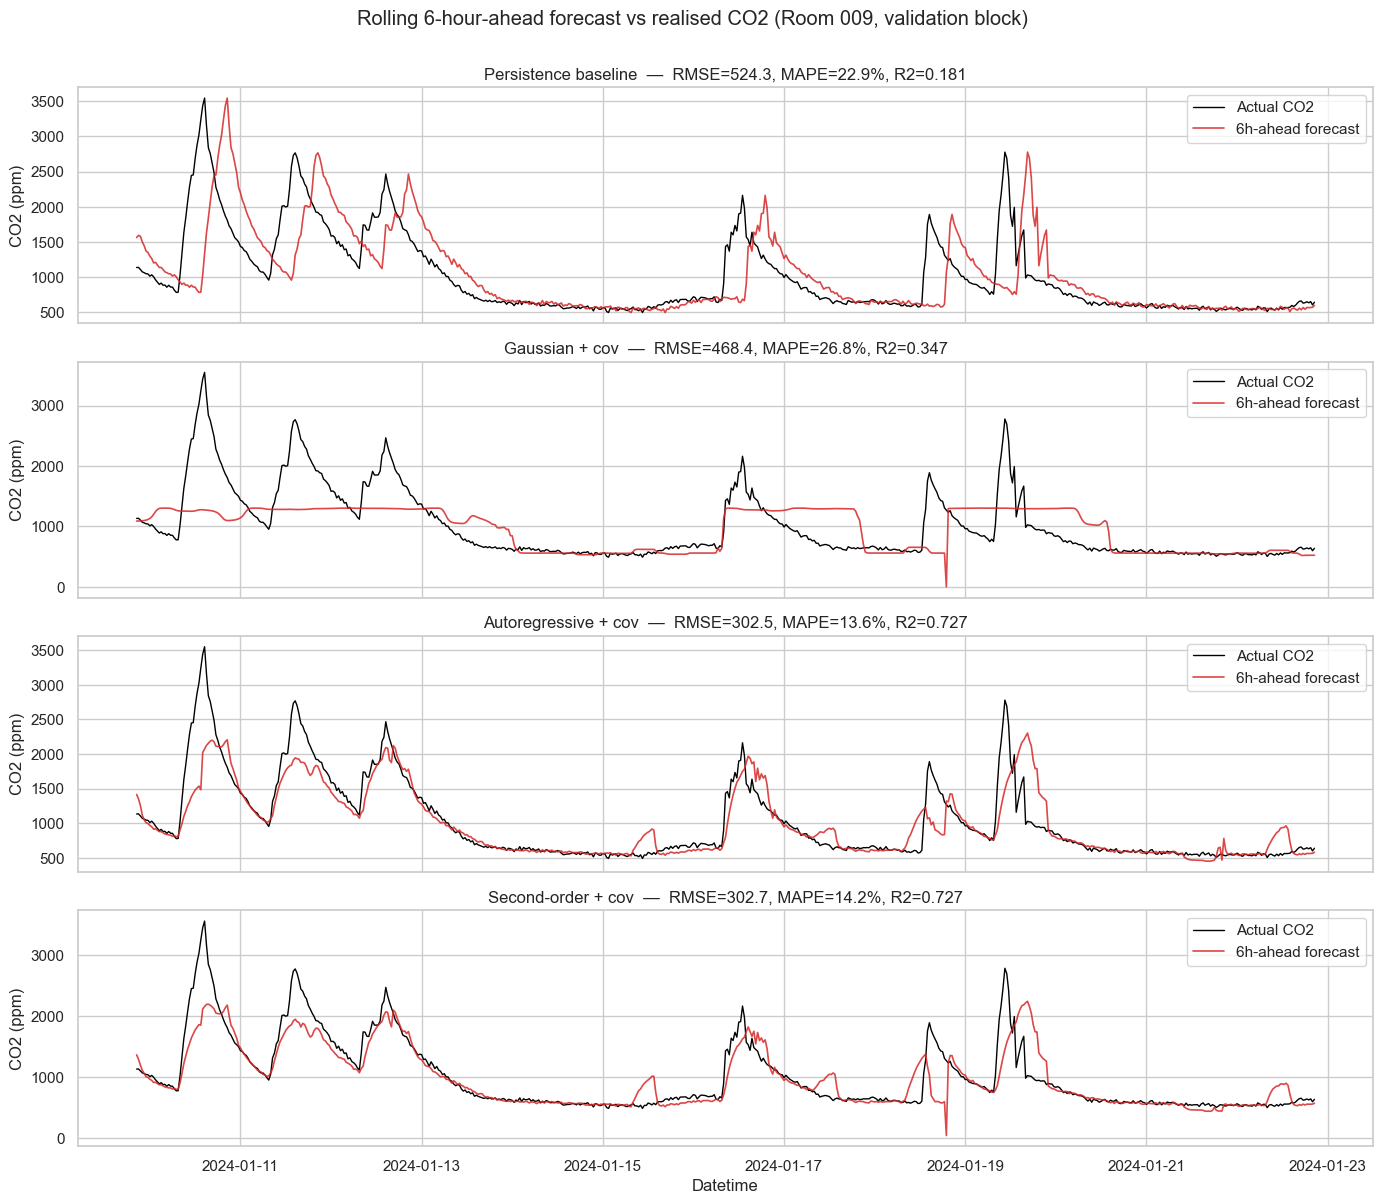

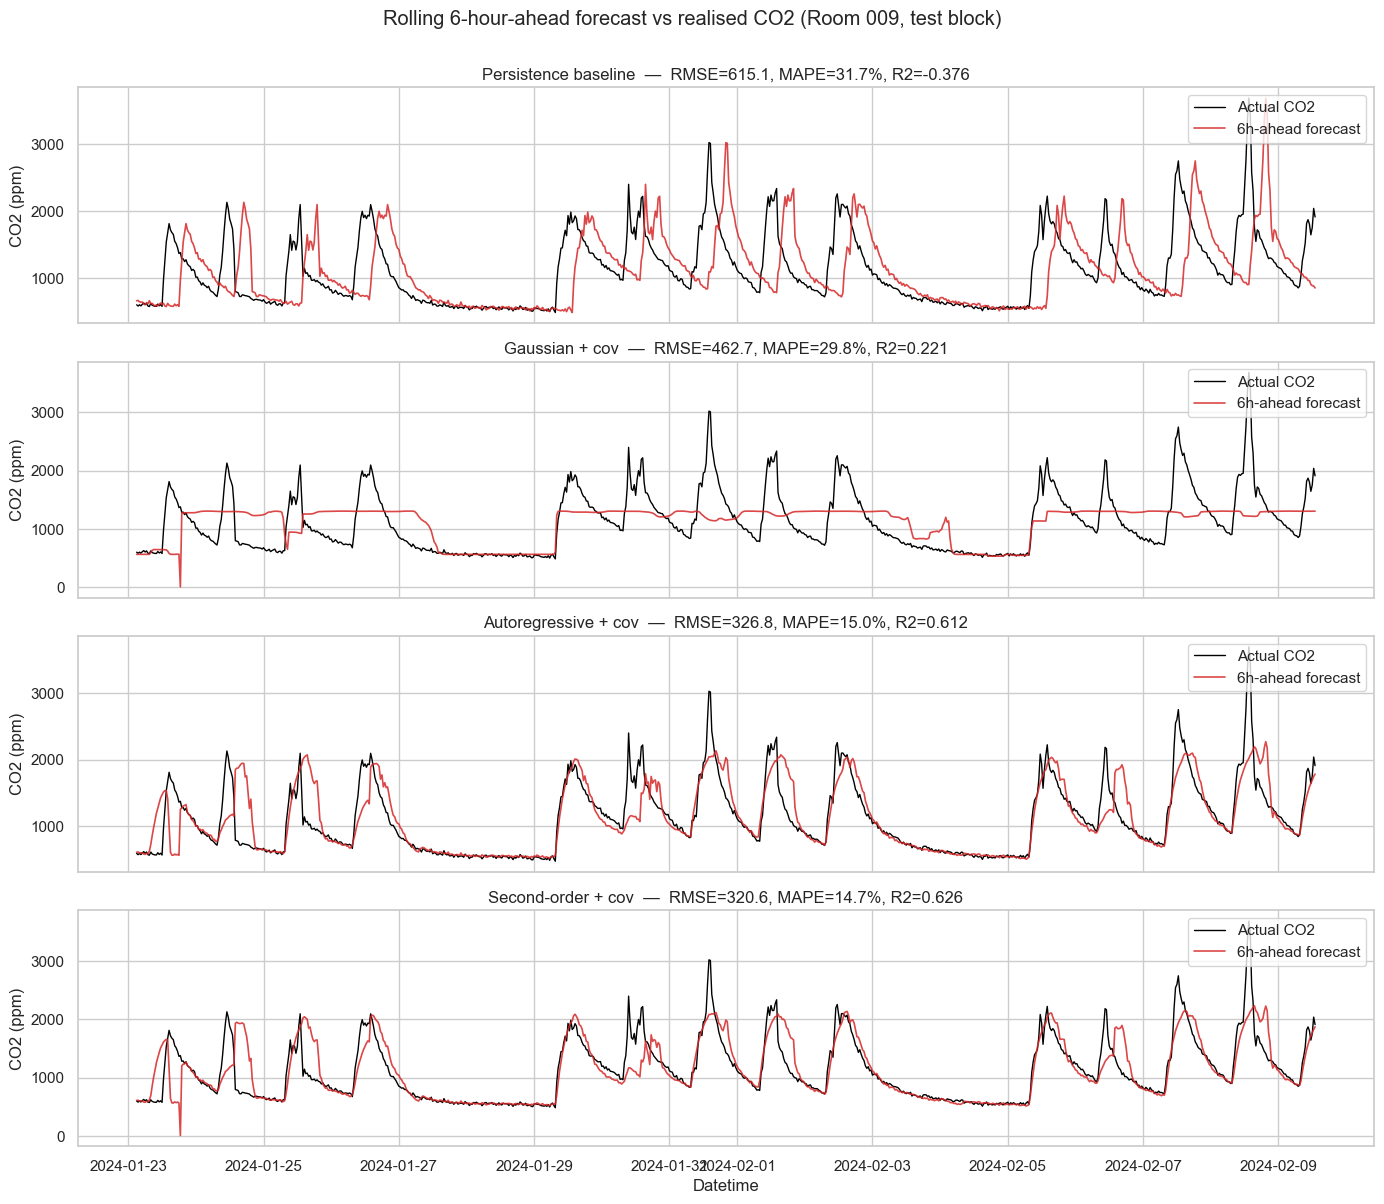

In [18]:
for block, results in block_results.items():
    fig, axes = plt.subplots(len(results), 1, figsize=(14, 3 * len(results)), sharex=True)
    for ax, (name, (td, yt, yp)) in zip(axes, results.items()):
        yt_j, yp_j = jnp.asarray(yt), jnp.asarray(yp)
        ax.plot(td, yt, color="black", lw=1.0, label="Actual CO2")
        ax.plot(td, yp, color="tab:red", lw=1.2, alpha=0.85, label=f"{HORIZON_HOURS}h-ahead forecast")
        ax.set_title(f"{name}  —  RMSE={rmse(yt_j, yp_j):.1f}, "
                     f"MAPE={mape(yt_j, yp_j):.1f}%, R2={r2_score(yt_j, yp_j):.3f}")
        ax.set_ylabel("CO2 (ppm)")
        ax.legend(loc="upper right")
    axes[-1].set_xlabel("Datetime")
    fig.suptitle(f"Rolling {HORIZON_HOURS}-hour-ahead forecast vs realised CO2 "
                 f"({room_name}, {block} block)", y=1.002)
    plt.tight_layout()
    plt.show()

### Forecast errors over the held-out blocks

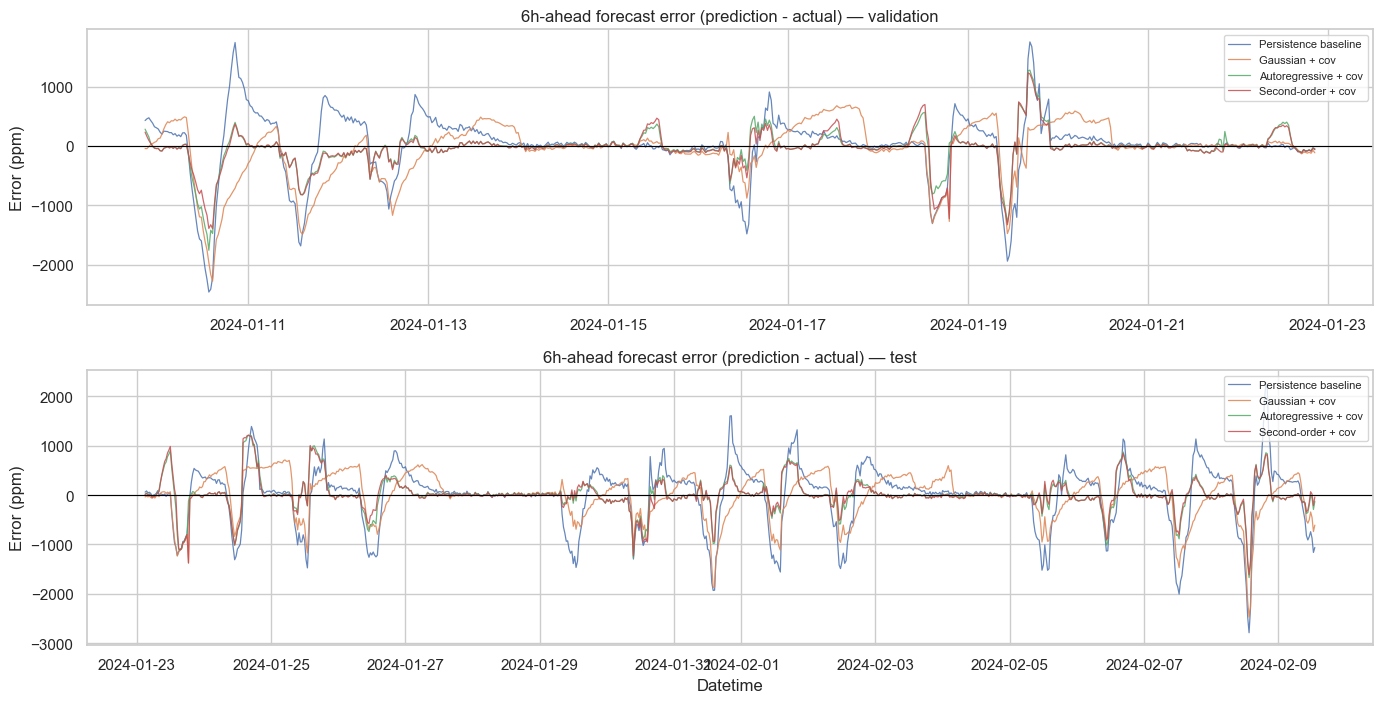

In [19]:
fig, axes = plt.subplots(len(block_results), 1, figsize=(14, 3.6 * len(block_results)))
for ax, (block, results) in zip(np.atleast_1d(axes), block_results.items()):
    for name, (td, yt, yp) in results.items():
        ax.plot(td, np.asarray(yp) - np.asarray(yt), lw=0.9, alpha=0.85, label=name)
    ax.axhline(0.0, color="black", lw=0.8)
    ax.set_title(f"{HORIZON_HOURS}h-ahead forecast error (prediction - actual) — {block}")
    ax.set_ylabel("Error (ppm)")
    ax.legend(loc="upper right", fontsize=8)
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
plt.tight_layout()
plt.show()

## Notes

- **Preprocessing lives in `drivers/clean_dtu_data.py`, not here.** Room, bin width, Fourier
  harmonics, weather columns and the split fractions are all arguments there; re-run
  `uv run python -m drivers.clean_dtu_data` and re-run this notebook to change any of them.
  `metadata.csv` records the baseline offset and the per-covariate training mean/std, so every
  transform applied to the arrays is reversible and auditable.
- **Validation decides, test reports.** Model choice — number of states, AR lags, Markov order,
  how many harmonics — is read off the validation column of the predictive table. Reading the
  test column and then going back to change a model turns test into a second validation set and
  the reported number stops being out-of-sample.
- Calibration is a pure level shift, so it leaves LL differences, residual diagnostics and RMSE
  untouched relative to the uncalibrated fit — what it buys is interpretable state means
  (ppm above a physical 400 ppm background) and comparability across rooms.
- Read the predictive table against the persistence baseline: at a 6 h horizon persistence is a
  genuinely hard benchmark on a series with a strong daily cycle, and beating it is what
  justifies the covariate transition.
- The AR model nests the Gaussian one at `phi = 0`, so its in-sample LL cannot be worse; whether
  the extra parameters pay off is what AIC/BIC and — more importantly — the out-of-sample
  6 h-ahead RMSE/R2 decide.
- The second-order model nests the first-order AR one too: its transition is seeded by an *exact*
  lift of the fitted `DynamicTransition` (`from_first_order`), so at the seed the two
  log-likelihoods coincide and the fit can only climb from there. What it adds is memory — the
  transition may depend on `s_{t-1}` as well as the covariates — at the cost of
  `STATES**ORDER * (STATES - 1)` baseline logits. The covariate effects are *tied over history*
  (`beta` is `(D, STATES, STATES - 1)`, indexed by the current base state), so the covariate budget
  is unchanged and the comparison isolates the memory.
- Read ΔBIC first for whether the extra baseline logits pay for themselves, but the 6 h-ahead
  RMSE/R² on the held-out blocks is what decides.
- Caveat on that LL: the emission **sigmas are not tied** across augmented states (only the means
  are, via `mu_vals`). The augmented states the chain almost never visits — see the occupancy grid
  printed next to the second-order fit — therefore let their sigma run toward 0, the standard
  unbounded-likelihood spike of a Gaussian mixture. Part of the LL gain is that artefact rather
  than genuine fit, which is one more reason to read the held-out RMSE and not the LL. Tying the
  sigmas to the current base state, as the means already are, is the fix worth trying next.
- The correlation heatmap is the guard on the covariate budget: the transition spends
  `D * STATES * (STATES - 1)` parameters on `beta`, so each extra Fourier harmonic costs 12
  parameters at `STATES = 3`, and near-collinear weather columns pay full price for information
  they already share. Extra covariates can only raise the in-sample LL, so let BIC and the
  validation RMSE decide, never the LL.